In [12]:
# ==========================================
# AUTORES
# Nathan Scremin
# Pedro Henrique Carvalho de Paula
# ==========================================

In [13]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score

In [14]:
# ==========================================
# SETUP INICIAL
# ==========================================
df = pd.read_csv('abt_churn.csv')

DATE_COL = 'dtRef'
TARGET = 'flagChurn'
ID_COL = 'idUsuario'

In [15]:
# ==========================================
# 1. S - SAMPLE (Amostragem)
# ==========================================
# Garantindo formato de data e ordenação
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(by=DATE_COL)

# Identificando safra de Out-of-Time (OOT)
max_date = df[DATE_COL].max()
mask_oot = (df[DATE_COL].dt.year == max_date.year) & (df[DATE_COL].dt.month == max_date.month)

df_oot = df[mask_oot].copy()
df_modelagem = df[~mask_oot].copy()

# Separando X e Y (removendo ID e Datas que não vão para o modelo)
X = df_modelagem.drop(columns=[TARGET, DATE_COL, ID_COL])
y = df_modelagem[TARGET]
X_oot = df_oot.drop(columns=[TARGET, DATE_COL, ID_COL])
y_oot = df_oot[TARGET]

# Split com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [16]:
# ==========================================
# 2. E - EXPLORE (Exploração)
# ==========================================
print("Valores Nulos no Treino:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# Feature Importance Inicial
dt_explore = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_explore.fit(X_train.fillna(X_train.median(numeric_only=True)), y_train)

feature_importances = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': dt_explore.feature_importances_
}).sort_values(by='Importância', ascending=False)

print("\nTop 5 Features Iniciais (Árvore):")
print(feature_importances.head(5))

Valores Nulos no Treino:
Series([], dtype: int64)

Top 5 Features Iniciais (Árvore):
                   Variável  Importância
25              qtdeDiasD14     0.664730
6   qtdeDiasUltimaTransacao     0.108517
35          propAvgQtdeDias     0.098009
30              qtdeDiasD28     0.053983
22          qtdePontosPosD7     0.038633


In [17]:
# ==========================================
# 2.1 Análise Bivariada (Apenas no Treino)
# ==========================================
# Unindo o X e y temporariamente para conseguir agrupar
df_explore = X_train.copy()
df_explore[TARGET] = y_train

# Selecionando apenas as colunas numéricas
colunas_numericas = df_explore.select_dtypes(include=['float64', 'int64']).columns

# Calculando a média das variáveis para quem deu Churn (1) e não deu (0)
analise_bivariada = df_explore.groupby(TARGET)[colunas_numericas].mean().T

print("Comparação de Médias (Churn 0 vs Churn 1):")
print(analise_bivariada.head(10)) # Mostrando as 10 primeiras variáveis

Comparação de Médias (Churn 0 vs Churn 1):
flagChurn                            0           1
qtdeTransacoes              295.784678   50.431725
qtdeDias                     28.983228    9.281828
mediaTransacoesDias           6.176668    3.953271
saldoPontos                1402.307797  444.286961
qtdePontosPos              2932.094288  664.115503
qtdePontosNeg             -1529.786491 -219.828542
qtdeDiasUltimaTransacao       6.581596   13.417351
qtdeDiasPrimeiraTransacao    96.439257   73.803901
qtdSkuDistintos               3.557117    2.184292
qtdeChatMessage             258.140979   40.875770


/tmp/ipykernel_2306/2867899462.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=feature_importances.head(10), palette='viridis')


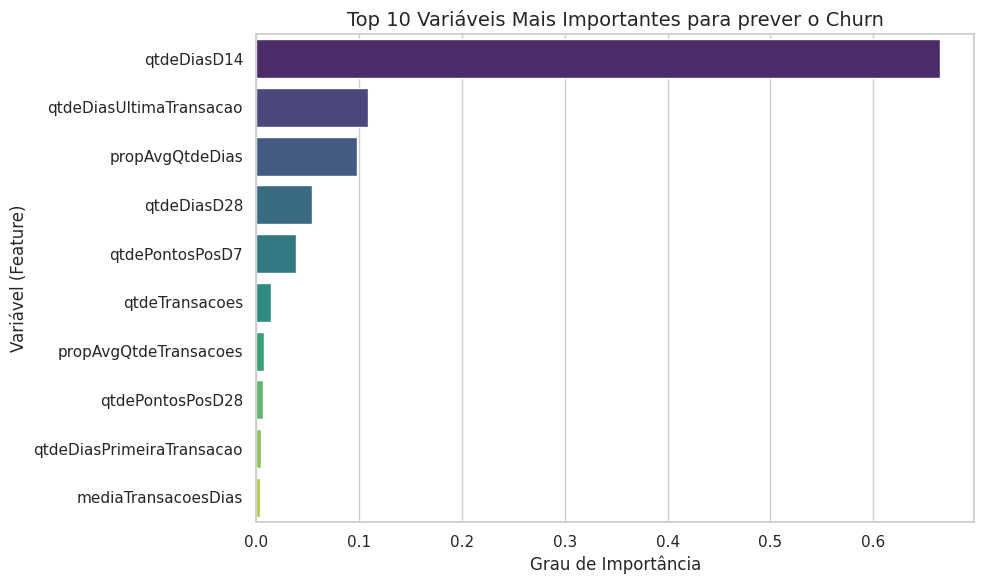

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Usando o dataframe 'feature_importances' que já criamos antes
sns.barplot(x='Importância', y='Variável', data=feature_importances.head(10), palette='viridis')

plt.title('Top 10 Variáveis Mais Importantes para prever o Churn', fontsize=14)
plt.xlabel('Grau de Importância', fontsize=12)
plt.ylabel('Variável (Feature)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2306/2442854120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=TARGET, y='qtdeDiasD14', data=df_explore, palette='Set2')


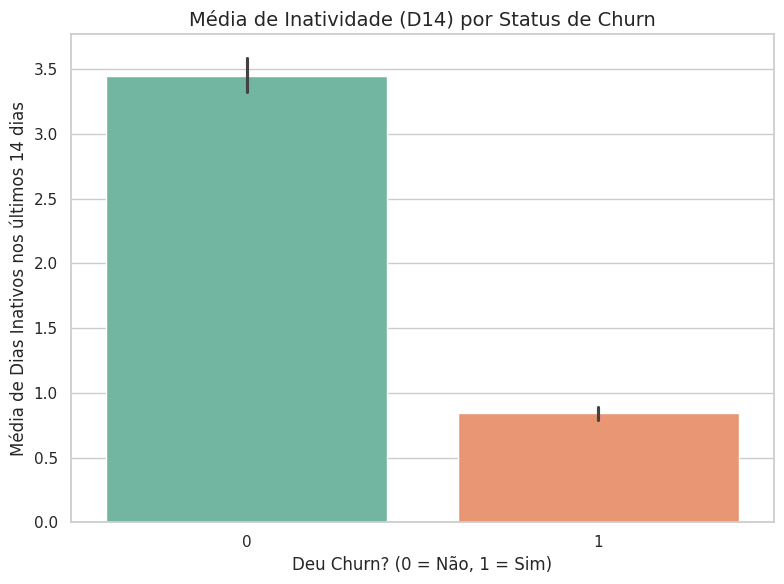

In [19]:
plt.figure(figsize=(8, 6))

# Comparando a variável mais importante (qtdeDiasD14) entre quem é churn e quem não é
sns.barplot(x=TARGET, y='qtdeDiasD14', data=df_explore, palette='Set2')

plt.title('Média de Inatividade (D14) por Status de Churn', fontsize=14)
plt.xlabel('Deu Churn? (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Média de Dias Inativos nos últimos 14 dias', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# 3. M - MODIFY (Modificação)
# ==========================================
vars_continuas = X_train.select_dtypes(include=np.number).columns.tolist()
vars_categoricas = X_train.select_dtypes(exclude=np.number).columns.tolist()

continuas_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('binning', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=200000))
])

categoricas_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='desconhecido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', continuas_transformer, vars_continuas),
        ('cat', categoricas_transformer, vars_categoricas)
    ])

In [21]:
# ==========================================
# 4. M - MODEL (Modelagem)
# ==========================================
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_distributions = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
}

random_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 11 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 12 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:3

In [22]:
# ==========================================
# 5. A - ASSESS (Avaliação)
# ==========================================
def avaliar(modelo, X_data, y_true, base_nome):
    pred = modelo.predict(X_data)
    proba = modelo.predict_proba(X_data)[:, 1]
    auc = roc_auc_score(y_true, proba)
    acc = accuracy_score(y_true, pred)
    print(f"{base_nome:<10} - ROC AUC: {auc:.4f} | Acurácia: {acc:.4f}")
    return proba

print("\nPerformance do Modelo:")
proba_tr = avaliar(best_model, X_train, y_train, "Treino")
proba_te = avaliar(best_model, X_test, y_test, "Teste")
proba_oo = avaliar(best_model, X_oot, y_oot, "OOT")

# Análise de Lift/Gains
df_gains = pd.DataFrame({'Churn_Real': y_test, 'Probabilidade': proba_te})
df_gains = df_gains.sort_values(by='Probabilidade', ascending=False)
df_gains['Decil'] = pd.qcut(df_gains['Probabilidade'].rank(method='first', ascending=False), 10, labels=False) + 1

lift_table = df_gains.groupby('Decil').agg(
    Qtd_Usuarios=('Churn_Real', 'count'),
    Churners_Capturados=('Churn_Real', 'sum')
).reset_index()

total_churners = lift_table['Churners_Capturados'].sum()
lift_table['%_Churners_Capturados'] = (lift_table['Churners_Capturados'] / total_churners) * 100
lift_table['%_Acumulado_Churners'] = lift_table['%_Churners_Capturados'].cumsum()

print("\nTabela de Ganhos / Lift (Base de Teste):")
print(lift_table.head(5).to_string(index=False))

# Exportar Pickle
with open('modelo_rf_churn.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("\n[!] Modelo treinado salvo como 'modelo_rf_churn.pkl'")


Performance do Modelo:
Treino     - ROC AUC: 0.8337 | Acurácia: 0.7549
Teste      - ROC AUC: 0.8289 | Acurácia: 0.7411
OOT        - ROC AUC: 0.8446 | Acurácia: 0.7789

Tabela de Ganhos / Lift (Base de Teste):
 Decil  Qtd_Usuarios  Churners_Capturados  %_Churners_Capturados  %_Acumulado_Churners
     1           104                   88              18.069815             18.069815
     2           104                   90              18.480493             36.550308
     3           104                   68              13.963039             50.513347
     4           104                   64              13.141684             63.655031
     5           104                   58              11.909651             75.564682

[!] Modelo treinado salvo como 'modelo_rf_churn.pkl'


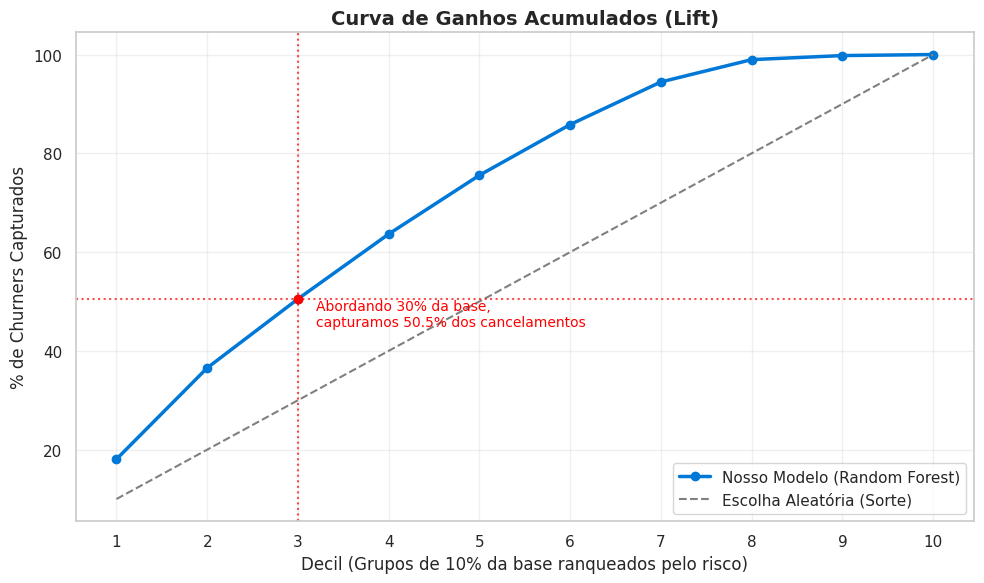

In [23]:
plt.figure(figsize=(10, 6))

# Linha do nosso Modelo
plt.plot(lift_table['Decil'], lift_table['%_Acumulado_Churners'],
         marker='o', linestyle='-', color='#0078D7', linewidth=2.5, label='Nosso Modelo (Random Forest)')

# Linha de Escolha Aleatória (Baseline)
plt.plot([1, 10], [10, 100], linestyle='--', color='gray', label='Escolha Aleatória (Sorte)')

plt.title('Curva de Ganhos Acumulados (Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Decil (Grupos de 10% da base ranqueados pelo risco)', fontsize=12)
plt.ylabel('% de Churners Capturados', fontsize=12)

# Adicionando anotação para destacar os 30%
plt.axvline(x=3, color='red', linestyle=':', alpha=0.7)
plt.axhline(y=50.5, color='red', linestyle=':', alpha=0.7)
plt.scatter(3, 50.5, color='red', zorder=5)
plt.text(3.2, 45, 'Abordando 30% da base,\ncapturamos 50.5% dos cancelamentos', color='red', fontsize=10)

plt.xticks(range(1, 11))
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()